In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [15]:
# Create State
class State(TypedDict):
    query: str
    answer: str
    # tool_result will contain the tools results with tool name and output of tools, with indexing
    tool_result: dict[str, str]

In [16]:
# Define tools
def calculator_tool(state: State) -> str:
    if "add" in state["query"].lower():
        return "2+2=4"
    elif "subtract" in state["query"].lower():
        return "4-2=2"
    elif "multiply" in state["query"].lower():
        return "2*2=4"
    elif "divide" in state["query"].lower():
        return "4/2=2"
    else:
        return "Unknown operation"
    
def greeting_tool(state: State) -> str:
    return "Hello! How can I assist you today?"

def general_knowledge_tool(state: State) -> str:
    return "The capital of France is Paris."


In [17]:
# Define router
def route_query(state: State) -> str:
    if "add" in state["query"].lower() or "subtract" in state["query"].lower() or "multiply" in state["query"].lower() or "divide" in state["query"].lower():
        return "calculator"
    elif "hello" in state["query"].lower() or "hi" in state["query"].lower():
        return "greeting"
    else:
        return "general_knowledge"

In [18]:
# Create Nodes
def calculator_node(state: State) -> State:
    response = calculator_tool(state)
    return {"answer":response}

def greeting_node(state: State) -> State:
    response = greeting_tool()
    return {"answer":response}

def general_knowledge_node(state: State) -> State:
    response = general_knowledge_tool()
    return {"answer":response}

In [19]:
# Create Graph
builder = StateGraph(State)

builder.add_node("router", lambda state: {})
builder.add_node("calculator", calculator_node)
builder.add_node("greeting", greeting_node)
builder.add_node("general_knowledge", general_knowledge_node)

builder.add_edge(START, "router")
builder.add_conditional_edges("router", route_query)
builder.add_edge("calculator", END)
builder.add_edge("greeting", END)
builder.add_edge("general_knowledge", END)

graph = builder.compile()

In [21]:
graph.invoke({
    "query": "divide"
})

{'query': 'divide', 'answer': '4/2=2'}

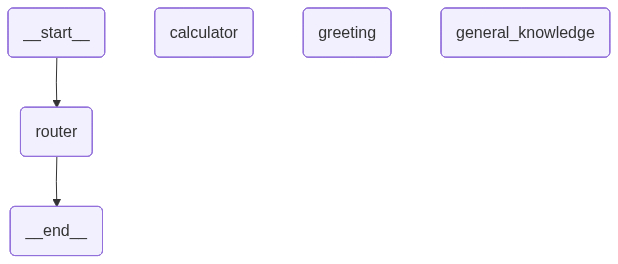

In [22]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))